In [1]:
import os
import json
from typing import List

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

from pprint import pprint

In [ ]:
PROJECT_HOME = "ABSOLUTE_PATH_TO_THE_PROJECT"
CODE_HOME = os.path.join(PROJECT_HOME, 'code')

import sys
sys.path.append(CODE_HOME)

In [ ]:
from models.uncertainty.dist_match.tree import DistMatchQRF
from models.uncertainty.dist_match.utils import match_ks_p_val

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
def matcher(x1, x2):
    return match_ks_stat(x1, x2) < 0.6

In [7]:
tree_path = os.path.join(PROJECT_HOME, "models_save/uc/qrf_ks_stat<0.1_error_normal_electricelectricity-normalized_darts-forest|100.pkl")

qrf = DistMatchQRF(
    alpha=0.1,
    n_quantile_bins=10,
    feature_dim=-1,
    matcher=matcher,
    match_mask=None,
    n_trees=10,
    bagging_ratio=0.9,
    verbose=False,
)
qrf.load_trees(tree_path)

In [8]:
def get_elec_file_dir(data_key: str):
    return os.path.join(PROJECT_HOME, f"outputs/{data_key}/wandb/latest-run/files/media/table/Eval_electricelectricity-normalized_plots")

def read_json(path: str):
    with open(path, "r") as file:
        data = json.load(file)
    cols = data["columns"]
    data = data["data"]
    data = [dict(zip(cols, datum)) for datum in data]
    return pd.DataFrame.from_records(data)

In [9]:
key = "darts_forest_dist_match_enbPI_electric_s30_260126_140743"
# key = "darts_forest_dist_match_synthetic_s10_280725_133342"

file_dir = get_elec_file_dir(key)
filename = os.listdir(file_dir)[0]

result_df = read_json(os.path.join(file_dir, filename))

In [10]:
result_df

,step,fc_y_hat,y_real,pi_high,pi_low
0,-516,0.562303,0.554386,0.554386,0.554386
1,-515,0.563193,0.545614,0.545614,0.545614
2,-514,0.588281,0.550000,0.550000,0.550000
3,-513,0.587136,0.523684,0.523684,0.523684
4,-512,0.522781,0.465351,0.465351,0.465351
...,...,...,...,...,...
1373,857,0.415035,0.356140,0.607194,0.312493
1374,858,0.421425,0.369737,0.554105,0.205078
1375,859,0.417197,0.354825,0.590496,0.245592
1376,860,0.424833,0.380263,0.518763,0.209557


In [11]:
tree = qrf.trees[0]
all_data = [node.get_values()[0].squeeze() for node in tree.leaf_nodes]
data_lens = np.cumsum([
    len(node.get_values()[0]) for node in tree.leaf_nodes
])
pca = PCA(n_components=2)
pca_data = []
pca_data.append(pca.fit_transform(all_data[-1]))
pca_data.extend(pca.transform(datum) for datum in all_data[:-1])

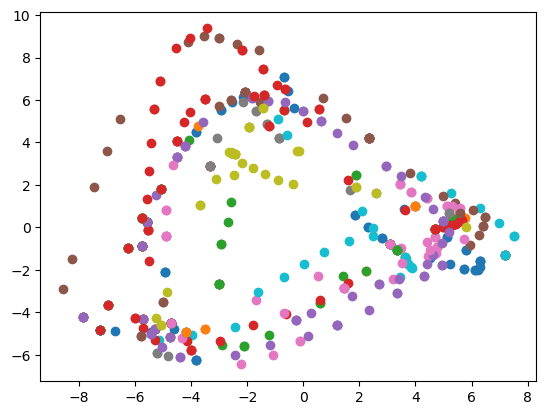

In [12]:
for datum in pca_data:
    plt.scatter(datum[:, 0], datum[:, 1])

In [13]:
tree = qrf.trees[1]

colors = []

tree_lens = np.array([len(node.get_values()[0]) for node in tree.leaf_nodes])
print(tree_lens)
node_ids = np.argsort(tree_lens)[::-1]
# print(tree_lens[node_ids])
# node_ids = node_ids[[2, 3, 4]]
node_ids = node_ids[[1, 2, 4]]
# print(tree_lens[node_ids])
nodes = [tree.leaf_nodes[idx] for idx in node_ids]

all_data = [node.get_values()[0].squeeze() for node in nodes]
all_targets = [node.get_values()[1].squeeze() for node in nodes]
leaf_labels = []
for i in range(len(nodes)):
    i_ids = nodes[i].get_values()[2]
    inter_map = np.zeros(len(i_ids)).astype(bool)

    for j in range(i+1, len(nodes)):
        j_ids = nodes[j].get_values()[2]
        inter_ids = np.isin(i_ids, j_ids)
        inter_map[inter_ids] = True
    
    all_data[i] = all_data[i][~inter_map]
    all_targets[i] = all_targets[i][~inter_map]
    leaf_labels.append(np.ones(len(all_data[i])) * i)

all_data = np.concatenate(all_data)
all_targets = np.concatenate(all_targets)
leaf_labels = np.concatenate(leaf_labels)

# pca = LinearDiscriminantAnalysis(n_components=2)
pca = NeighborhoodComponentsAnalysis(n_components=2)
pca_data = pca.fit_transform(all_data, leaf_labels)

[15 14 16 15 18 20 22 11 12 13 19 23 25 28 40  8 41  6  5 48  6 10  6 14
  8  7  7  8 10 35 76]


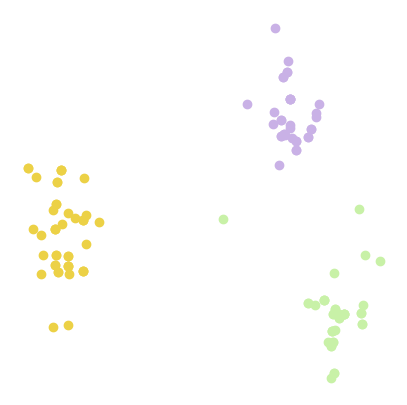

In [14]:
colors = ["#ECD146", "#C8F1A7", "#C9B1E6"] # Yellow, Green, Purple

fig, ax = plt.subplots(1, figsize=(5, 5))
for i, color in enumerate(colors):
    leaf_ids = np.where(leaf_labels == i)[0]
    ax.scatter(pca_data[leaf_ids, 0], pca_data[leaf_ids, 1], color=color)
ax.axis('off')
fig.show()

In [15]:
def get_cdf(_data):
    data_sorted = np.sort(_data)
    cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, cdf

In [16]:
def plot_cdf(data, color: str = '#ECD146'):
    data_sorted, cdf_data = [], []
    print(data.shape)
    for datum in data:
        datum_sorted, datum_cdf = get_cdf(datum)
        data_sorted.append(datum_sorted)
        cdf_data.append(datum_cdf)

    data_sorted = np.stack(data_sorted)
    cdf_data = np.stack(cdf_data)

    # Mean, Std Dev
    mean_cdf = np.mean(cdf_data, axis=0)
    std_cdf = 0.12

    plt.figure(figsize=(7, 7))

    # each CDF 
    for i in range(len(data)):
        plt.plot(data_sorted[i], cdf_data[i], color='gray', alpha=0.3)

    # Yellow: color='#ECD146'
    # Green: color='#C8F1A7'
    # Purple: color='#C9B1E6'
    # Mean CDF 
    plt.plot(data_sorted[0], mean_cdf, color='red', linewidth=2, label='Mean CDF')

    # Std
    plt.fill_between(data_sorted[0], np.maximum(mean_cdf - std_cdf, 0), np.minimum(mean_cdf + std_cdf, 1), 
                    color=color, alpha=0.7)

    # Chart
    plt.xlabel('X')
    plt.ylabel('Probability')
    plt.xlim([-2.5, 1.5])
    plt.ylim([0, 1])
    # plt.legend()
    plt.grid(True)

    plt.show()

(45, 100)


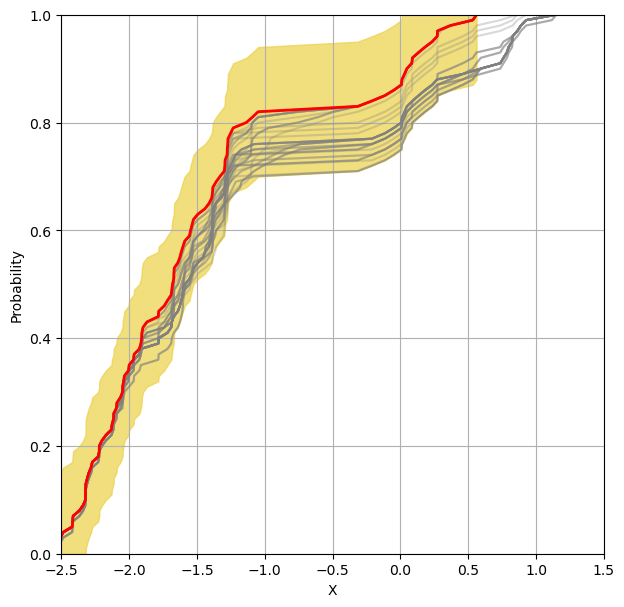

(39, 100)


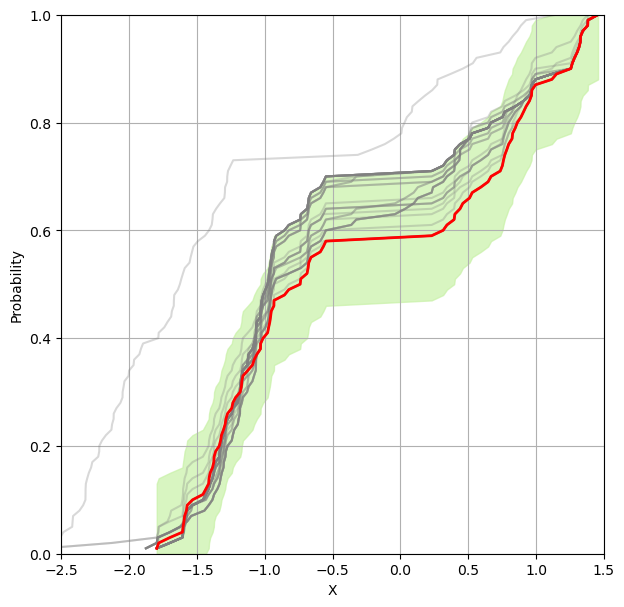

(35, 100)


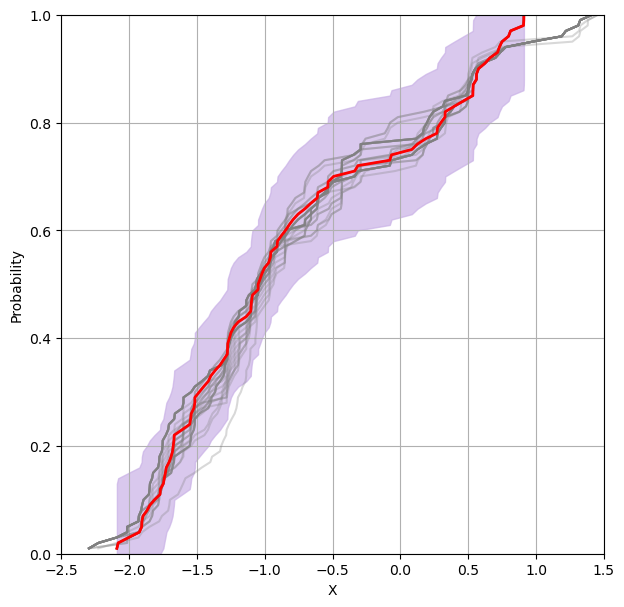

In [17]:
cdf_plot_data = []
for i, color in enumerate(colors):
    leaf_ids = np.where(leaf_labels == i)[0]
    cdf_plot_data.append(all_data[leaf_ids, :])
    plot_cdf(cdf_plot_data[-1], color=color)

In [24]:
def plot_collected_cdfs(datasets, colors):
    assert len(datasets) == len(colors)

    plot_data = []

    for data in datasets:
        data_sorted, cdf_data = [], []
        print(data.shape)
        for datum in data:
            datum_sorted, datum_cdf = get_cdf(datum)
            data_sorted.append(datum_sorted)
            cdf_data.append(datum_cdf)

        data_sorted = np.stack(data_sorted)
        cdf_data = np.stack(cdf_data)
        
        mean_cdf = np.mean(cdf_data, axis=0)
        plot_data.append((data_sorted[0], mean_cdf))
        

    plt.figure(figsize=(6, 7))

    # each CDF 
    for (i, ((data_sorted, mean_cdf), color)) in enumerate(zip(plot_data, colors)):
        plt.plot(data_sorted, mean_cdf, color=color, linewidth=10, label=f'{i}th CDF')

    # Chart
    plt.xlabel('X', fontsize=25)
    plt.ylabel('Probability', fontsize=25,)
    plt.xlim([-1.5, 1.5])
    plt.ylim([0, 1])
    plt.tick_params(axis='both', which='major', labelsize=25)

    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()

    # plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

(45, 100)
(39, 100)
(35, 100)


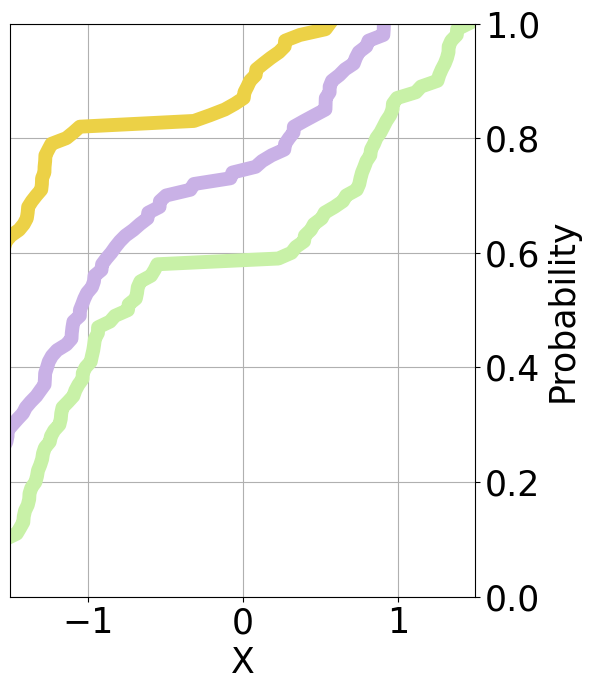

In [25]:
plot_collected_cdfs(cdf_plot_data, colors=colors)

In [20]:
def compute_ks(data1, data2):
    total_p_val = 0
    n1 = len(data1)
    n2 = len(data2)
    for i1 in range(n1):
        for i2 in range(i1, n2):
            total_p_val += (1 if i1 == i2 else 2) * match_ks_p_val(data1[i1], data2[i2])

    return total_p_val / (n1 * n2)

In [21]:
colors = ["#ECD146", "#C8F1A7", "#C9B1E6"] # Yellow, Green, Purple

for i, color1 in enumerate(colors):
    leaf_ids1 = np.where(leaf_labels == i)[0]
    for j, color2 in enumerate(colors[i:]):
        j = j + i
        leaf_ids2 = np.where(leaf_labels == j)[0]
        avg_p_val = compute_ks(all_data[leaf_ids1, :], all_data[leaf_ids2, :])
        print((i, color1), (j, color2), avg_p_val)

(0, '#ECD146') (0, '#ECD146') 0.8216914672534129
(0, '#ECD146') (1, '#C8F1A7') 0.0419706301852623
(0, '#ECD146') (2, '#C9B1E6') 1.4834454214741503e-05
(1, '#C8F1A7') (1, '#C8F1A7') 0.7989770507249957
(1, '#C8F1A7') (2, '#C9B1E6') 0.040854898991332905
(2, '#C9B1E6') (2, '#C9B1E6') 0.8405201172183591


In [22]:
[len(node.get_values()[0]) for node in tree.leaf_nodes]

[15,
 14,
 16,
 15,
 18,
 20,
 22,
 11,
 12,
 13,
 19,
 23,
 25,
 28,
 40,
 8,
 41,
 6,
 5,
 48,
 6,
 10,
 6,
 14,
 8,
 7,
 7,
 8,
 10,
 35,
 76]

In [13]:
def bar_plot_leaf_lens_dist(qrf):
    n_trees = len(qrf.trees)

    tree_lens = []
    for tree in qrf.trees:
        cur_node_lens = [len(node.get_values()[0]) for node in tree.leaf_nodes]
        cur_node_lens = sorted(cur_node_lens, reverse=True)
        tree_lens.append(cur_node_lens)

    min_n_leafs = min((len(leafs) for leafs in tree_lens))

    tree_ratios = []
    for i in range(len(tree_lens)):
        leafs = tree_lens[i][:min_n_leafs]
        leafs_sum = sum(leafs)
        leafs_norm = [leaf_len / leafs_sum for leaf_len in leafs]
        tree_ratios.append(leafs_norm)
    
    pprint(tree_lens)
    pprint(tree_ratios)

    # labels = [f"Tree {i + 1}"for i in range(n_trees)]
    # data = np.array(tree_ratios)
    labels = ["Tree 1"]
    data = np.array(tree_ratios).mean(0, keepdims=True)
    data_cum = data.cumsum(axis=1)

    top_k_colors = plt.colormaps["RdYlGn"](np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(9, 1))
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.tick_params("y", labelsize=20)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    if len(labels) == 1:
        ax.yaxis.set_visible(False)
        ax.xaxis.set_visible(True)
        ax.tick_params("x", labelsize=18)
        x_ticks = np.concatenate([[0], data_cum[0]])
        x_ticks = (x_ticks[1:] - x_ticks[:-1]) / 2 + x_ticks[:-1]
        ax.set_xticks(x_ticks)
        x_ticklabels = [f"N={i+1}" for i in range(len(x_ticks))]
        x_ticklabels[-1] = '...'
        ax.set_xticklabels( x_ticklabels)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    bar_formatter = np.vectorize(lambda x: f"{int(x*100)}%")

    for i, color in enumerate(top_k_colors):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.975, color=color)

        r, g, b, _ = color
        text_color = "white" if r * g * b < 0.5 else "grey"
        ax.bar_label(
            rects,
            labels=bar_formatter(widths),
            label_type="center",
            fontweight='bold',
            color=text_color,
            fontsize=23,
        )

    fig.tight_layout()

    return fig, ax

[[50, 44, 6, 3],
 [52, 36, 9, 6, 3],
 [48, 40, 9, 6, 4],
 [43, 40, 7, 6, 6, 6, 5, 5, 5, 4],
 [54, 35, 11, 4],
 [47, 35, 8, 8, 5, 5, 4, 4],
 [49, 37, 10, 5, 5, 4, 3],
 [48, 28, 12, 7, 7, 6, 6, 5, 4, 4],
 [47, 31, 15, 7, 6],
 [50, 33, 8, 8, 5, 4, 4, 4]]
[[0.4854368932038835,
  0.42718446601941745,
  0.05825242718446602,
  0.02912621359223301],
 [0.5048543689320388,
  0.34951456310679613,
  0.08737864077669903,
  0.05825242718446602],
 [0.46601941747572817,
  0.3883495145631068,
  0.08737864077669903,
  0.05825242718446602],
 [0.4479166666666667, 0.4166666666666667, 0.07291666666666667, 0.0625],
 [0.5192307692307693,
  0.33653846153846156,
  0.10576923076923077,
  0.038461538461538464],
 [0.47959183673469385,
  0.35714285714285715,
  0.08163265306122448,
  0.08163265306122448],
 [0.48514851485148514,
  0.36633663366336633,
  0.09900990099009901,
  0.04950495049504951],
 [0.5052631578947369,
  0.29473684210526313,
  0.12631578947368421,
  0.07368421052631578],
 [0.47, 0.31, 0.15, 0.07],
 [

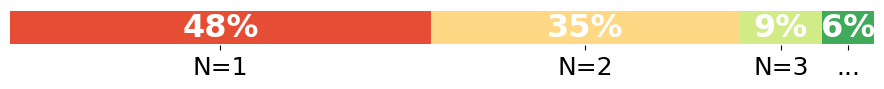

In [87]:
tree_path = os.path.join(PROJECT_HOME, "models_save/uc/qrf_ks_stat<0.2_error_normal_data_darts-forest|100.pkl")

qrf = DistMatchQRF(
    alpha=0.1,
    n_quantile_bins=10,
    feature_dim=-1,
    matcher=matcher,
    match_mask=None,
    n_trees=10,
    bagging_ratio=0.9,
    verbose=False,
)
qrf.load_trees(tree_path)


fig, *_ = bar_plot_leaf_lens_dist(qrf)
fig.savefig("tree_leaf_len_dist.pdf")